# Ti64 Statistical Modelling
## Modelling Beta approach curves from literature to produce a beta volume fraction calculator
### Rory Atlasi Barker, Guy Bowker

This notebook can be used to filter beta-approach curves for Ti64 volume fraction measurments from literature.
Change the temperature range, microstructure, strain rate, or other options in the example cells at the bottom to plot the corresponding curves for those conditions.
Functions can be found next to this notebook in `utils.py`.
To add data from a paper, simply create a new file in this repository named after the paper authors as shown containing the data as a `.csv` file.
Then add the papers metadata and relative filepath to the `beta-approach_curves.yaml` file.

In [73]:
# Import libraries and funcs from utils.py

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
from scipy.optimize import curve_fit
import statistics
import sys
import yaml
from yaml.loader import FullLoader
from yaml.loader import SafeLoader

path = os.path.abspath("Beta-approach_curves/")
sys.path.append(path)
from beta_approach_curve_utils import load_yml
from beta_approach_curve_utils import sort_curve
from beta_approach_curve_utils import curve_filter
from beta_approach_curve_utils import curve_plotter

%matplotlib inline

Load `beta-approach_curves.yml` file, read in data for each paper as pandas dataframe, and show all papers:

In [2]:

# define alloy which you want curve data for
alloy = 'Ti-6Al-4V'

# load metadata from yml file
database = load_yml(alloy)



Experiments: 
dict_keys(['Diamond_2022'])

Papers: 
dict_keys(['Sesha_2000', 'Semiatin_2002', 'Tamiri_2005', 'Reddy_2006', 'Motyka_2012', 'Villa_2019', 'He_2020', 'Janda_2022'])


## Filter the data

Filter out and plot only the desired beta approach curves from the literature data.

Save paper metadata and beta-approach curves to a dictionary `filtered_database`, which can be saved to a `.pkl` file to be plotted alongside other data in a different code. The `filtered_database` dictionary can be easily parsed to plot all the data on the same plot.

In [9]:

# Define desired parameters:
parameters = {                                  # USER OPTIONS GUIDE
              'heating_rate' : 'any',            # float in C/s or 'any' as str
              'Strain_rate_s-1' : 'any',         # float in /s or 'any' as str
              'In_situ_heating' : 'any',         # 'induction', 'gleeble' or 'any' as str
    
              'exclusions' : ['Diamond_2022', 'Villa_2019', 'Motyka_2012']    # dataset keys to exclude (empty if none)
             }


# Filter beta approach curve data by def params:
filtered_database = curve_filter(database, parameters);


Chosen heating rate:any

Diamond_2022 IN EXCLUSIONS LIST.
Including Sesha_2000
Including Semiatin_2002
Including Semiatin_2002
Including Semiatin_2002
Including Tamiri_2005
Including Reddy_2006
Motyka_2012 IN EXCLUSIONS LIST.
Villa_2019 IN EXCLUSIONS LIST.
Villa_2019 IN EXCLUSIONS LIST.
Villa_2019 IN EXCLUSIONS LIST.
Including He_2020
Including Janda_2022


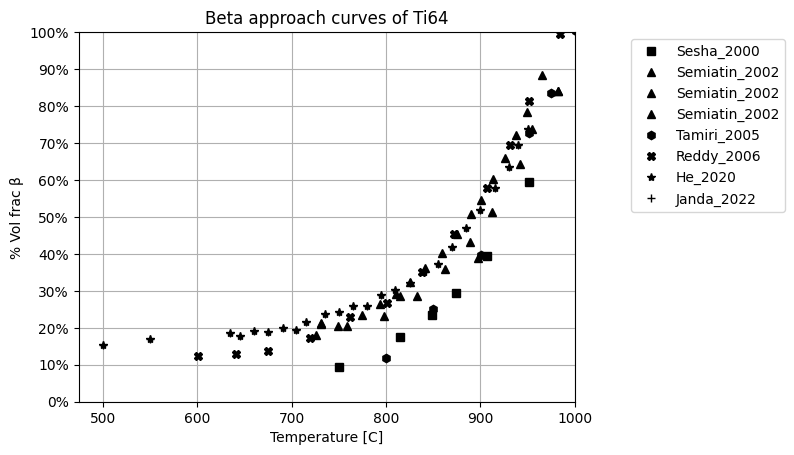

In [10]:
%matplotlib inline

curve_plotter(filtered_database)

pickle.dump(filtered_database, open('beta-approach_curves.pkl', 'wb'))

First, estimate a model relationship between temperature T and volume fraction of beta phase.
An exponential function is expected to fit the trend of beta volume fraction with increasing temperature.
Here is where the choice of data to include in the previous step becomes important, because some data is more unreliable, has less datapoints, etc.

$\Large{β_{volfrac\%} = a + b^{c(T+d)}}$

Ranges for each term have been determined via application of the function to a variety of beta approach datasets:

$-30<a<20$

$1.003<b<1.005$

$1<c<3$

$-610<d<-30$

In [11]:
def testfunc(T, a, b, c, d):
    """Model exponential function for beta approach curves.
    Comments:
       a appears to be a correction term in the same units as VF (unitless)
       b is the term to which the exponential including T is raised
       c is multiplied by the temperature after some correction d
       d is a addition correction to T in the same units as T (celsius)
    """
    return a + (b)**(c*(T+d))

Next, use this model curve to predict/extrapolate between measured datapoints for each curve in the literature.
Plot the model curves for each dataset and see the maximum and minimum bounds for any given temperature or volume fraction of beta.
We can also predict the beta-transus temperature for each dataset.
Note including only papers with high-temperature ranges of beta volume fraction measurments introduces much more uncertainty at lower temperature, and vice versa.


To get a definitive answer to the question "what is the beta volume fraction at temperature $X$?" the model curves need to be combined.
One model beta approach curve weighted by the contributions of many measured beta approach curves is the most reliable to answer this question.
We have `T` and `betavolfrac` values from $500C$ to $1000C$ in $1C$ steps for each dataset -
we can mean over these values to get a mean beta approach curve:

To find the beta transus temperature is the reverse question however, "what is the temperature at beta volume fraction $100$?".

In [56]:
def plot_betaapproach(database):
    for datatype in database.keys():
        for key in database[datatype].keys():
            database[datatype][key]['model_curves'] = []
            for curve_num, curve in enumerate(database[datatype][key]['Curves']):
                measured_T = curve['data'].iloc[:,0]
                measured_volfracbeta = curve['data'].iloc[:,1]

                try: # fit curve to data
                    param, param_cov = curve_fit(testfunc, measured_T, measured_volfracbeta)
                except:
                    print(f"An exponential growth function could not be fit to {key}.")
                    pass
                
                model_T = np.arange(500,1100, 1)
                model_betafrac = testfunc(model_T, param[0], param[1], param[2], param[3])
                model_curve = {
                                "model_T": model_T,
                                "model_betafrac": model_betafrac,
                              }
                database[datatype][key]['model_curves'].append(pd.DataFrame.from_dict(model_curve))

                print(key)
#                 plt.figure()
                plt.plot(measured_T, measured_volfracbeta, 'o', color ='red',
                         label =f"Datapoints") # for plot alltogther
                plt.plot(model_T, model_betafrac,
                         ',', color ='blue', label =f"Model curves")
    return database

In [69]:

def plot_mean_curve(database):
    # First make list of all model curve dataframes:
    list_of_dfs = []
    list_of_transi = []
    for datatype in database.keys():
        for key in database[datatype].keys():
            for curve_num, curve in enumerate(database[datatype][key]['model_curves']):
                list_of_dfs.append(curve)
                
    mean_rows = []
    for rows in zip(*[df.iloc[:, 1] for df in list_of_dfs]):
        mean_row = sum(rows) / len(rows)
        mean_rows.append(mean_row)

    T = database[datatype][key]['model_curves'][0].iloc[:,0]
    mean_beta_volfrac = mean_rows
    
    mean_curve = {"T" : T,
                  "beta_volfrac" : mean_beta_volfrac,
                 }

    plt.plot(T, mean_beta_volfrac,
             color='k', linewidth=5,
             label='Mean beta approach curve')
    
    return mean_curve

In [76]:

def plot_median_curve(database):
    # First make list of all model curve dataframes:
    list_of_dfs = []
    list_of_transi = []
    for datatype in database.keys():
        for key in database[datatype].keys():
            for curve_num, curve in enumerate(database[datatype][key]['model_curves']):
                list_of_dfs.append(curve)
                
    median_rows = []
    for rows in zip(*[df.iloc[:, 1] for df in list_of_dfs]):
        median_row = statistics.median(rows)
        median_rows.append(median_row)

    T = database[datatype][key]['model_curves'][0].iloc[:,0]
    median_beta_volfrac = median_rows
    
    median_curve = {"T" : T,
                  "beta_volfrac" : median_beta_volfrac,
                 }

    plt.plot(T, median_beta_volfrac,
             color='g', linewidth=2,
             label='Median beta approach curve')
    
    return median_curve

In [70]:

def plot_minmax_curves(database):
    # First make list of all model curve dataframes:
    list_of_dfs = []
    for datatype in database.keys():
        for key in database[datatype].keys():
            for curve_num, curve in enumerate(database[datatype][key]['model_curves']):
                list_of_dfs.append(curve)
                
    min_rows = []
    max_rows = []
    for rows in zip(*[df.iloc[:, 1] for df in list_of_dfs]):
        min_row = min(rows)
        min_rows.append(min_row)
        max_row = max(rows)
        max_rows.append(max_row)

    T = database[datatype][key]['model_curves'][0].iloc[:,0]
    min_beta_volfrac = min_rows
    max_beta_volfrac = max_rows

    min_curve = {"T" : T,
                     "beta_volfrac": min_beta_volfrac,
                    }
    max_curve = {"T" : T,
                     "beta_volfrac": max_beta_volfrac,
                    }

    plt.plot(T, min_beta_volfrac,
             color='k', linestyle='dashed',
             label='Minimum beta approach curve')
    plt.plot(T, max_beta_volfrac,
             color='k', linestyle='dashed',
             label='Maximum beta approach curve')
    
    return min_curve, max_curve


Sesha_2000
Semiatin_2002
Semiatin_2002
Semiatin_2002
Tamiri_2005
Reddy_2006
He_2020
Janda_2022


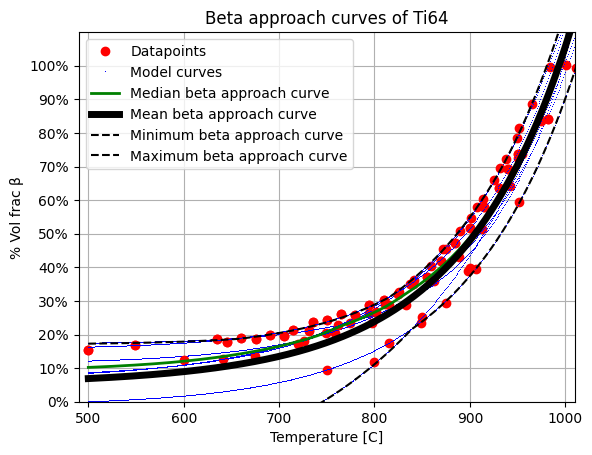

In [77]:

# Plot all beta approach data and curves
filtered_database = plot_betaapproach(filtered_database) 
# plot mean curve
mean_curve = plot_mean_curve(filtered_database)
# plot median curve
median_curve = plot_median_curve(filtered_database)
# plot minmax curves
min_curve, max_curve = plot_minmax_curves(filtered_database)

# plot options
plt.title('Beta approach curves of Ti64')
plt.xlabel(f"Temperature [C]")
plt.xlim(490, 1010)
plt.ylabel(f"% Vol frac β")
plt.ylim(0, 110)
plt.yticks([0,10,20,30,40,50,60,70,80,90,100],
           ["0%","10%","20%","30%","40%","50%","60%","70%","80%","90%","100%"])
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.grid()

With this mean curve of models of all datasets, we can return an answer for beta volume fraction \% given an input temperature T:

We'd also like the uncertainty in this prediction which depends on the maximum and minimum beta volume fraction considering all curves for a given temperature. As can already be seen, uncertainty decreases as temperature increases.

In [78]:

input_Vfrac = 90
input_T = 800

T = beta_approach_curve["T"]
beta_volfrac = mean_curve["beta_volfrac"]
median_beta_volfrac = median_curve["beta_volfrac"]
min_volfrac = min_curve["beta_volfrac"]
max_volfrac = max_curve["beta_volfrac"]
    
T_out = T[np.where(np.around(beta_volfrac)==input_Vfrac)[0][0]]
volfrac_out = beta_volfrac[np.where(np.around(T)==input_T)[0][0]]
median_volfrac_out = median_beta_volfrac[np.where(np.around(T)==input_T)[0][0]]
max_volfrac_out = max_volfrac[np.where(np.around(T)==input_T)[0][0]]
min_volfrac_out = min_volfrac[np.where(np.around(T)==input_T)[0][0]]

print(f"Predicted T for vol frac {input_Vfrac}: {T_out}")
print(f"Predicted max volfrac for T {input_T}: {max_volfrac_out}")
print(f"Predicted mean volfrac for T {input_T}: {volfrac_out}")
print(f"Predicted median volfrac for T {input_T}: {median_volfrac_out}")
print(f"Predicted min volfrac for T {input_T}: {min_volfrac_out}")

Predicted T for vol frac 90: 980
Predicted max volfrac for T 800: 28.889972194102654
Predicted mean volfrac for T 800: 23.84446821020721
Predicted median volfrac for T 800: 26.613367289450178
Predicted min volfrac for T 800: 11.129031375512813
